<a href="https://colab.research.google.com/github/laceywang11/MSSP6070/blob/main/Assignment1_Lacey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **A. Import files**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving data_academic_performance.xlsx to data_academic_performance.xlsx


In [4]:
import pandas as pd
import numpy as np
df = pd.read_excel("data_academic_performance.xlsx")
xls = pd.ExcelFile("data_academic_performance.xlsx")
xls.sheet_names

['Citation',
 'Description of Categorical',
 'Description of Numerical',
 'SABER11_SABERPRO']

In [5]:
df = pd.read_excel("data_academic_performance.xlsx", sheet_name="SABER11_SABERPRO")
df.head(5)

,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


# **B. Descriptive data**

In [6]:
df.groupby("GENDER")["G_SC"].describe()

,count,mean,std,min,25%,50%,75%,max
GENDER,,,,,,,,
F,5043.0,161.278207,22.332939,76.0,146.0,162.0,177.0,242.0
M,7368.0,163.690825,23.582616,37.0,147.0,164.0,180.0,247.0


By Gender

Differences by gender are minimal.
Male students have a slightly higher mean score (163.69) than female students (161.28), a difference of about 2.4 points.
Since both groups show similar variability, gender does not appear to be a major factor influencing academic outcomes among engineering students.

In [7]:
df.groupby("STRATUM")["G_SC"].describe()

,count,mean,std,min,25%,50%,75%,max
STRATUM,,,,,,,,
0,14.0,154.000000,21.321712,116.0,142.0,152.5,167.0,196.0
Stratum 1,1709.0,152.352838,21.937401,77.0,138.0,152.0,167.0,220.0
Stratum 2,4029.0,158.199305,22.278029,72.0,143.0,158.0,174.0,237.0
Stratum 3,4045.0,163.815328,21.693970,75.0,149.0,164.0,179.0,247.0
Stratum 4,1578.0,172.002535,21.469094,91.0,158.0,174.0,188.0,243.0
Stratum 5,633.0,177.387046,21.543236,37.0,165.0,179.0,192.0,246.0
Stratum 6,403.0,181.511166,21.879401,91.0,170.0,184.0,194.5,242.0


By Socioeconomic Stratum

Students’ performance shows a clear upward trend across socioeconomic strata.
Those in Stratum 1 have an average global score of 152.35, while students in Stratum 6 reach 181.51—a gap of nearly 30 points.
Although the variation (standard deviation around 21–22) is similar across groups, the steady increase in mean scores suggests that students from higher socioeconomic backgrounds consistently perform better.
This result highlights how socioeconomic inequality continues to shape educational outcomes.

In [8]:
df["EDU_FATHER"] = df["EDU_FATHER"].str.strip().str.lower()
df["EDU_MOTHER"] = df["EDU_MOTHER"].str.strip().str.lower()
replace_dict = {
    "0": "unknown",
    "ninguno": "unknown",
    "not sure": "unknown",
    "none": "unknown",
}

df["EDU_FATHER"] = df["EDU_FATHER"].replace(replace_dict)
df["EDU_MOTHER"] = df["EDU_MOTHER"].replace(replace_dict)

The parental education variables were cleaned by merging equivalent categories (e.g., 0, Ninguno, Not sure → Unknown) and ordering education levels from primary to postgraduate to facilitate interpretation.

In [9]:
df.groupby("EDU_MOTHER")["G_SC"].describe()

,count,mean,std,min,25%,50%,75%,max
EDU_MOTHER,,,,,,,,
complete primary,713.0,155.336606,22.012293,81.0,140.0,155.0,170.00,230.0
complete professional education,3059.0,168.845374,22.978321,91.0,153.0,170.0,185.50,246.0
complete secundary,3106.0,158.470702,21.949597,76.0,143.0,159.0,174.00,247.0
complete technique or technology,1495.0,163.242140,21.943495,91.0,148.0,163.0,179.00,234.0
incomplete primary,541.0,154.853974,21.636024,94.0,140.0,155.0,171.00,232.0
incomplete professional education,502.0,166.685259,22.931830,37.0,153.0,168.0,183.00,243.0
incomplete secundary,1056.0,155.672348,21.928635,72.0,140.0,156.0,171.25,210.0
incomplete technical or technological,341.0,161.879765,20.744388,102.0,147.0,164.0,176.00,214.0
postgraduate education,997.0,175.636911,22.119758,100.0,161.0,178.0,190.00,242.0


In [10]:
df.groupby("EDU_MOTHER")["G_SC"].mean().sort_values()

,G_SC
EDU_MOTHER,
incomplete primary,154.853974
complete primary,155.336606
incomplete secundary,155.672348
unknown,157.859155
complete secundary,158.470702
incomplete technical or technological,161.879765
complete technique or technology,163.242140
incomplete professional education,166.685259
complete professional education,168.845374


By Mother’s Education

A similar positive relationship is found for mothers’ education.
Students whose mothers hold postgraduate degrees average 175.64, compared to 155.34 for those whose mothers completed primary education—a difference of around 20 points.
Intermediate categories such as complete professional education (168.85) and complete technique or technology (163.24) follow the same pattern.
Although the trend is consistent, the effect of mother’s education appears slightly smaller than that of fathers, which might reflect differences in household roles or exposure to academic networks.

In [11]:
df.groupby("EDU_FATHER")["G_SC"].describe()

,count,mean,std,min,25%,50%,75%,max
EDU_FATHER,,,,,,,,
complete primary,824.0,155.195388,22.410767,78.0,140.00,155.0,171.00,230.0
complete professional education,3016.0,167.765915,23.030089,76.0,152.00,169.0,185.00,247.0
complete secundary,2843.0,158.785790,22.114288,72.0,144.00,159.0,175.00,228.0
complete technique or technology,1194.0,164.033501,22.165359,75.0,149.00,164.0,179.75,228.0
incomplete primary,735.0,155.729252,20.942412,81.0,141.00,156.0,170.50,232.0
incomplete professional education,425.0,166.917647,22.685198,37.0,153.00,168.0,182.00,228.0
incomplete secundary,1091.0,156.535289,21.736989,76.0,141.00,157.0,172.00,220.0
incomplete technical or technological,277.0,162.101083,21.881198,99.0,147.00,162.0,178.00,224.0
postgraduate education,1085.0,176.985253,21.734132,110.0,163.00,179.0,192.00,242.0


In [12]:
df.groupby("EDU_FATHER")["G_SC"].mean().sort_values()

,G_SC
EDU_FATHER,
complete primary,155.195388
incomplete primary,155.729252
incomplete secundary,156.535289
complete secundary,158.785790
unknown,159.445283
incomplete technical or technological,162.101083
complete technique or technology,164.033501
incomplete professional education,166.917647
complete professional education,167.765915


By Father’s Education

Students’ academic performance rises steadily with fathers’ education levels.
Those whose fathers have postgraduate degrees average 176.99, compared to about 155.20 for students whose fathers completed only primary education, a gap of more than 20 points.
Middle categories such as complete technique or technology (164.03) and complete professional education (167.77) fit the same pattern.
This suggests that paternal education plays a strong role in shaping students’ learning outcomes, possibly through family expectations and access to educational resources.

In [30]:
subjects = ["QR_PRO", "WC_PRO"]
means_by_gender = df.groupby("GENDER")[subjects].mean().round(2)
numbers_by_gender = df.groupby("GENDER")[subjects].size()
print(means_by_gender)
print(numbers_by_gender)

        QR_PRO  WC_PRO
GENDER                
F        71.89   56.62
M        81.20   51.71
GENDER
F    5043
M    7368
dtype: int64


Males average 81.20 in QR_PRO and 51.71 in WC_PRO; females average 71.89 in QR_PRO and 56.62 in WC_PRO. This implies a +9.31 raw mean gap favoring males in quantitative reasoning and a −4.91 gap favoring females in writing. Sample sizes are large (F = 5,043; M = 7,368), so these means are likely stable. These are unadjusted comparisons (no controls for stratum or parental education) and should be interpreted as descriptive differences, not causal effects.

# C.**Visualization**

In [15]:
mean_by_gender = df.groupby("GENDER")["G_SC"].mean()
mean_by_gender

,G_SC
GENDER,
F,161.278207
M,163.690825


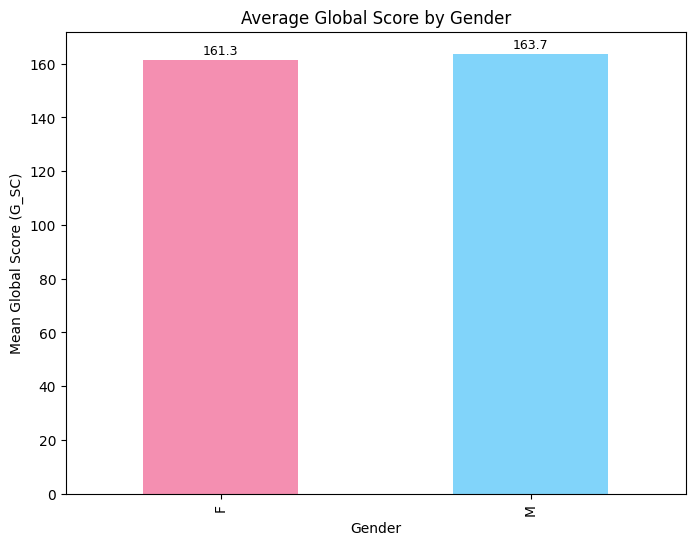

In [16]:
import matplotlib.pyplot as plt
ax_gender = mean_by_gender.plot(
    kind="bar", figsize=(8, 6),
    color=["#F48FB1", "#81D4FA"])
plt.title("Average Global Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean Global Score (G_SC)")
ax_gender.bar_label(ax_gender.containers[0], fmt="%.1f", fontsize=9, padding=2)
plt.show()

The bar chart compares the average Global Score (G_SC) between male and female students.
On average, male students scored slightly higher (163.7) than female students (161.3).
Although the difference is small (around 2 points), the visual clearly shows that male students performed marginally better overall.
This pattern aligns with the descriptive statistics results, suggesting a subtle but consistent gender gap in global assessment performance.

In [17]:
df["STRATUM"] = df["STRATUM"].astype(str)
mean_by_stratum = df.groupby("STRATUM")["G_SC"].mean()
mean_by_stratum

,G_SC
STRATUM,
0,154.000000
Stratum 1,152.352838
Stratum 2,158.199305
Stratum 3,163.815328
Stratum 4,172.002535
Stratum 5,177.387046
Stratum 6,181.511166


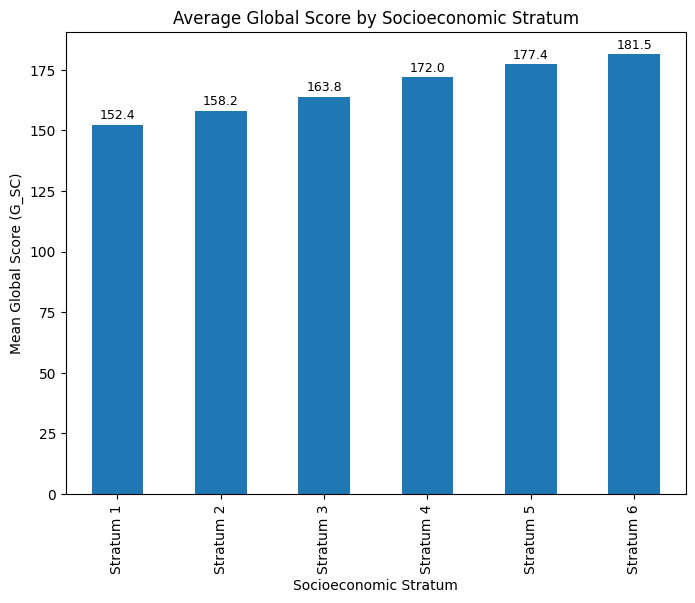

In [18]:
mean_by_stratum = mean_by_stratum.drop("0", errors="ignore")
ax_stratum = mean_by_stratum.plot(
    kind="bar", figsize=(8, 6))
plt.title("Average Global Score by Socioeconomic Stratum")
plt.xlabel("Socioeconomic Stratum")
plt.ylabel("Mean Global Score (G_SC)")
ax_stratum.bar_label(ax_stratum.containers[0], fmt="%.1f", fontsize=9, padding=2)
plt.show()

This bar chart shows the average global score by socioeconomic stratum.
The bar chart clearly illustrates that higher strata correspond to higher academic performance.
Students from lower strata scored below 160 on average, while those from upper strata reached around 180.
This upward pattern suggests that students’ socioeconomic background has a strong influence on their overall achievement.

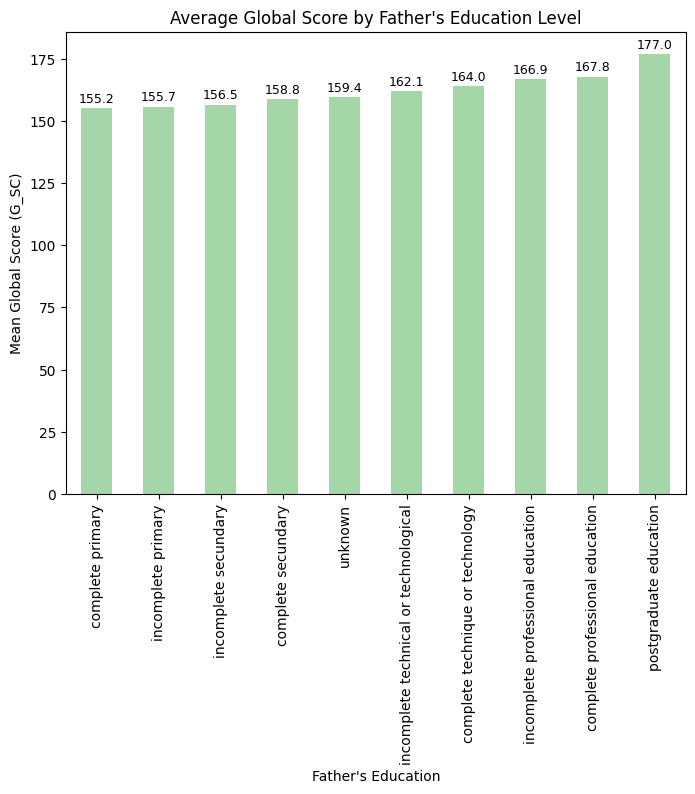

In [19]:
mean_by_father = df.groupby("EDU_FATHER")["G_SC"].mean().sort_values()
ax_father = mean_by_father.plot(
    kind="bar",
    color="#A5D6A7",
    figsize=(8, 6)
)
plt.title("Average Global Score by Father's Education Level")
plt.xlabel("Father's Education")
plt.ylabel("Mean Global Score (G_SC)")
ax_father.bar_label(ax_father.containers[0], fmt="%.1f", fontsize=9, padding=2)
plt.show()

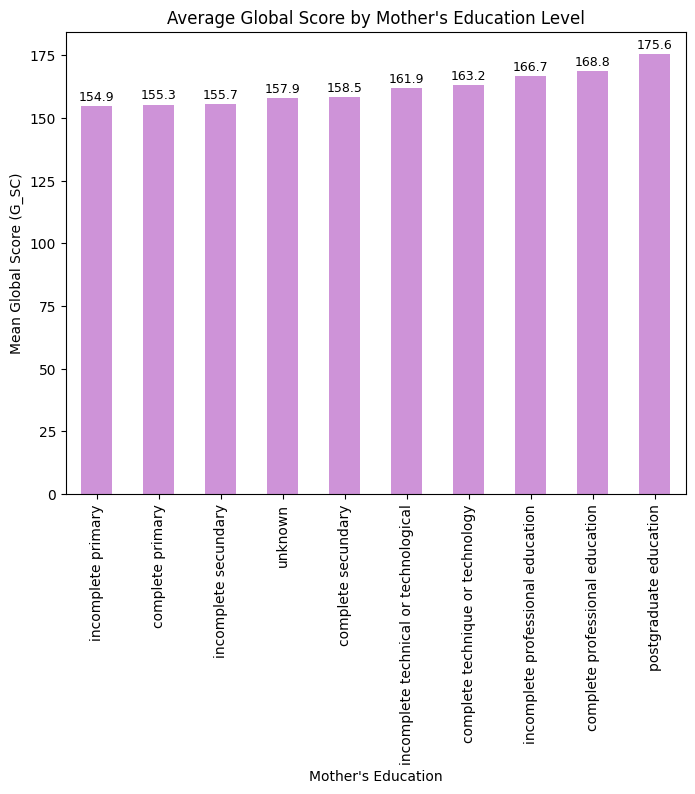

In [20]:
mean_by_mother = df.groupby("EDU_MOTHER")["G_SC"].mean().sort_values()
ax_mother = mean_by_mother.plot(
    kind="bar",
    color="#CE93D8",
    figsize=(8, 6)
)
plt.title("Average Global Score by Mother's Education Level")
plt.xlabel("Mother's Education")
plt.ylabel("Mean Global Score (G_SC)")
ax_mother.bar_label(ax_mother.containers[0], fmt="%.1f", fontsize=9, padding=2)
plt.show()

The bar charts make the pattern clearer than in the descriptive tables.
For father’s education, students whose fathers completed only primary education scored around 155–157 points, while those with professional or postgraduate education averaged around 176–178 points, a difference of about 20 points.
Similarly, for mother’s education, the average score rises from roughly 156 among students with mothers who did not finish primary school to nearly 176 among those whose mothers hold postgraduate degrees.

These bar charts highlight a consistent upward trend:
each increase in parental education level corresponds to a gradual rise of 2–4 points in students’ mean global scores.
Compared to the descriptive statistics, the visualization more vividly illustrates this gradient — showing that parental education strongly correlates with academic achievement, likely reflecting differences in home learning environments and academic support.

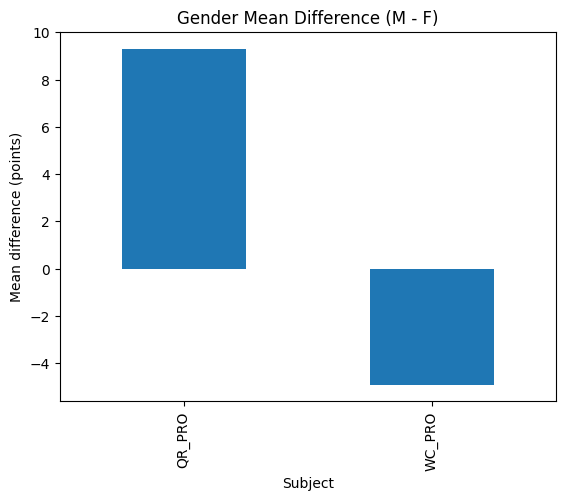

In [32]:
diff = (means_by_gender.loc["M"] - means_by_gender.loc["F"]).round(2)

plt.figure()
diff.plot(kind="bar")
plt.title("Gender Mean Difference (M - F)")
plt.xlabel("Subject")
plt.ylabel("Mean difference (points)")
plt.show()

This figure plots the raw mean gap between male and female students for two subjects.

QR_PRO: The bar is positive (≈ +9.31), indicating males score higher on average in quantitative reasoning.

WC_PRO: The bar is negative (≈ −4.91), indicating females score higher on average in writing.

# **D.Statistical data**

In [21]:
df["GENDER_M"] = df["GENDER"].map({"F": 0, "M": 1})

from statsmodels.formula.api import ols
model_gender = ols('G_SC ~ C(GENDER_M)', data=df).fit()
print(model_gender.summary())

                            OLS Regression Results                            
Dep. Variable:                   G_SC   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     32.71
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           1.10e-08
Time:                        22:08:32   Log-Likelihood:                -56569.
No. Observations:               12411   AIC:                         1.131e+05
Df Residuals:                   12409   BIC:                         1.132e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          161.2782      0.325  

The OLS regression shows that gender has a statistically significant but small effect on students’ global scores (F = 32.71, p < 0.001).
On average, males scored about 2.41 points higher than females (β = 2.41, p < 0.001).
However, the R² value (0.003) suggests that gender explains less than 1% of the variance in students’ performance.

In [22]:
s = df.dropna(subset=["STRATUM","G_SC"]).copy()
s["STRATUM"] = s["STRATUM"].astype(str).str.strip()
s = s[s["STRATUM"] != "0"]

model_stratum = ols('G_SC ~ C(STRATUM)', data=s).fit()
print(model_stratum.summary())

                            OLS Regression Results                            
Dep. Variable:                   G_SC   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     286.1
Date:                Tue, 14 Oct 2025   Prob (F-statistic):          1.43e-290
Time:                        22:08:32   Log-Likelihood:                -55845.
No. Observations:               12397   AIC:                         1.117e+05
Df Residuals:                   12391   BIC:                         1.117e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

The OLS regression reveals a clear, statistically significant upward trend across socioeconomic strata (F = 286.1, p < 0.001).
Compared to students in Stratum 1 (M = 152.35), average global scores increase steadily, reaching +29 points higher in Stratum 6.
The R² value (0.103) indicates that socioeconomic stratum explains about 10% of the total variance in students’ performance.

In [23]:
from statsmodels.formula.api import ols

model_mother = ols('G_SC ~ C(EDU_MOTHER)', data=df).fit()
print(model_mother.summary())

                            OLS Regression Results                            
Dep. Variable:                   G_SC   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.073
Method:                 Least Squares   F-statistic:                     106.1
Date:                Tue, 14 Oct 2025   Prob (F-statistic):          5.46e-192
Time:                        22:08:36   Log-Likelihood:                -54383.
No. Observations:               12023   AIC:                         1.088e+05
Df Residuals:                   12013   BIC:                         1.089e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

The OLS regression shows that mother’s education level has a statistically significant effect on students’ global scores (F(9,12013)=106.1, p<.001, R²=0.074). Students whose mothers completed higher education—especially professional or postgraduate programs—scored about 13 to 20 points higher on average than those whose mothers only completed primary school. This suggests a clear positive association between maternal education and academic performance, although the effect size remains moderate, explaining about 7% of the total score variation.

In [24]:
model_father = ols('G_SC ~ C(EDU_FATHER)', data=df).fit()
print(model_father.summary())

                            OLS Regression Results                            
Dep. Variable:                   G_SC   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     107.4
Date:                Tue, 14 Oct 2025   Prob (F-statistic):          1.81e-194
Time:                        22:08:38   Log-Likelihood:                -54364.
No. Observations:               12020   AIC:                         1.087e+05
Df Residuals:                   12010   BIC:                         1.088e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

The OLS regression indicates that father’s education level is significantly associated with students’ global scores (F(9,12010)=107.4, p<.001, R²=0.075). On average, students whose fathers completed professional or postgraduate education scored about 12 to 22 points higher than those whose fathers only completed primary school. Similar to the results for mothers, the relationship is statistically significant but moderate in strength, with father’s education explaining roughly 7.5% of the variance in students’ performance.

In [25]:
model_parents = ols('G_SC ~ C(EDU_MOTHER) + C(EDU_FATHER)', data=df).fit()
print(model_parents.summary())

                            OLS Regression Results                            
Dep. Variable:                   G_SC   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     67.92
Date:                Tue, 14 Oct 2025   Prob (F-statistic):          4.13e-236
Time:                        22:08:40   Log-Likelihood:                -53974.
No. Observations:               11959   AIC:                         1.080e+05
Df Residuals:                   11940   BIC:                         1.081e+05
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

The OLS regression combining both parents’ education levels shows that parental education significantly predicts students’ global scores (F(18,11940)=67.9, p<.001, R²=0.093). Together, parents’ education explains about 9.3% of the variation in performance.

Relative to the baseline (“complete primary”), higher education levels for both parents are associated with notably higher scores. For example, children whose parents hold a complete professional education or postgraduate degree score on average 7–15 points higher than those with only primary education. Most coefficients for higher education levels are statistically significant (p<.05), indicating a consistent upward trend.

Overall, both mother’s and father’s education independently and positively contribute to student achievement, with the father’s postgraduate degree showing the largest single effect (+14.2 points).

In [35]:
m_qr_ctl = ols("QR_PRO ~ C(GENDER) + C(STRATUM) + C(EDU_MOTHER) + C(EDU_FATHER)", data=df).fit()
m_wc_ctl = ols("WC_PRO ~ C(GENDER) + C(STRATUM) + C(EDU_MOTHER) + C(EDU_FATHER)", data=df).fit()
print(m_qr_ctl.summary())
print(m_wc_ctl.summary())

                            OLS Regression Results                            
Dep. Variable:                 QR_PRO   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     50.11
Date:                Tue, 14 Oct 2025   Prob (F-statistic):          7.03e-236
Time:                        22:29:42   Log-Likelihood:                -53699.
No. Observations:               11959   AIC:                         1.075e+05
Df Residuals:                   11933   BIC:                         1.076e+05
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

QR_PRO (quantitative): Gender (M–F) = +9.23 points (SE ≈ 0.40, p < .001), R² = 0.095, N = 11,959.
→ After adjusting for socioeconomic stratum and parental education, males score about 9.2 points higher on average in quantitative reasoning; the effect is statistically significant, with a modest share of variance explained.

WC_PRO (writing): Gender (M–F) = −5.13 points (SE ≈ 0.55, p < .001), R² = 0.034, N = 11,959.
→ With the same controls, females score about 5.1 points higher in writing; significant, with smaller model fit than QR_PRO.

After controlling for background, gender gaps remain subject-specific: advantage for males in quantitative reasoning and for females in writing. Model R² values are modest (≈9.5% and 3.4%), suggesting these controls help but do not fully account for performance differences, supporting subject-targeted supports (e.g., quantitative help and writing support) rather than blanket gender policies.